# Fig3f

**author**: laquitainesteeve@gmail.com

**purpose**: plot reyes probe traces summed over all cells

**tested on**:
* Ubuntu 24.04.1 LTS (32 cores, 188 GB RAM, Intel(R) Core(TM) i9-14900K ＠3.2 GHz/5.8 GHz) with RTX 5090 GPU with 40GB VRAM (GPU not needed)

**Execution time**: 40 secs

In [10]:
# SETUP PACKAGES 
%load_ext autoreload
%autoreload 2

import os 
import numpy as np
from matplotlib import pyplot as plt
from datetime import datetime
import spikeinterface as si 
import pandas as pd

print(si.__version__)

# SET PROJECT PATH
PROJ_PATH = "/home/steeve/steeve/epfl/code/spikebias"
os.chdir(PROJ_PATH)

# import custom packages
from spikeinterface import extract_waveforms
from spikeinterface import preprocessing as spre

# SET PARAMETERS
CELL_ID = '3754013'   # the most active near-probe pyramidal cell
DISTANT_CHANNEL = 0
NEARBY_CHANNEL = 71
FREQ_MIN = 300
MS_BEFORE = 3       # ms
MS_AFTER = 3        # ms
LOAD_WE_IF_EXISTS = False  # load waveforms if already extracted
CHUNKS = 50000
N_JOBS = 1
WE_JOB_KWARGS = dict(n_jobs=N_JOBS, chunk_size=800000, progress_bar=True)

# SETUP PATH
RAW_LFP_TRACE_FILE_PATH = "dataset/00_raw/recording_reyes_summed_traces"
SPIKE_FILE_PATH = "dataset/00_raw/sorting_reyes_summed_traces"
WAVE_PATH = "dataset/01_intermediate/waveforms/reyes_summed/"

savefig_cfg = {"transparent":True, "dpi": 400}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
0.100.8


## Custom functions

In [11]:
def align_waveforms(wfs, ref_channel=71):
    """Align waveforms across all channels using the negative peak
    of a reference channel.

    Args:
        wfs: shape (n_spikes, n_samples, n_channels)
        ref_channel: channel to use for peak detection

    Returns:
        aligned_wfs: shape (n_spikes, n_samples, n_channels)
    """
    n_spikes, n_samples, n_channels = wfs.shape
    center = n_samples // 2

    # find negative peak on reference channel for each spike
    peak_ixs = np.argmin(wfs[:, :, ref_channel], axis=1)

    aligned_wfs = np.zeros_like(wfs)
    for i in range(n_spikes):
        shift = center - peak_ixs[i]
        for ch in range(n_channels):
            aligned_wfs[i, :, ch] = np.roll(wfs[i, :, ch], shift)

    return aligned_wfs

## Extract all waveforms

In [12]:
%%time

# load raw data
Recording = si.load_extractor(RAW_LFP_TRACE_FILE_PATH)
Sorting = si.load_extractor(SPIKE_FILE_PATH)

# preprocess voltage traces
Recording = spre.bandpass_filter(Recording, freq_min=FREQ_MIN, freq_max=(Recording.sampling_frequency/2)-1)
Recording = spre.common_reference(Recording, reference="global", operator="median")

# extract waveforms (5 GB)
We = extract_waveforms(
    Recording,
    Sorting,
    WAVE_PATH,
    sparse=False,
    ms_before=MS_BEFORE,
    ms_after=MS_AFTER,
    max_spikes_per_unit=None,
    unit_batch_size=None,
    overwrite=True if LOAD_WE_IF_EXISTS == False else False,
    seed=0,
    load_if_exists=LOAD_WE_IF_EXISTS,
    **WE_JOB_KWARGS,
)

/home/steeve/steeve/epfl/code/spikebias/envs/spikebias/lib/python3.9/site-packages/spikeinterface/core/base.py:1079: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.101.2 is recommended
  warnings.warn(
<timed exec>:10: DeprecationWarning: load_if_exists=True/false is deprcated. Use load_waveforms() instead.
/home/steeve/steeve/epfl/code/spikebias/envs/spikebias/lib/python3.9/site-packages/spikeinterface/core/baserecordingsnippets.py:244: UserWarning: There is no Probe attached to this recording. Creating a dummy one with contact positions
  warn("There is no Probe attached to this recording. Creating a dummy one with contact positions")


extract waveforms memmap multi buffer:   0%|          | 0/1 [00:00<?, ?it/s]

CPU times: user 2.39 s, sys: 333 ms, total: 2.72 s
Wall time: 2.72 s


## Setup cell and electrode coordinates

In [13]:
# x,y,z
cell_coord = np.array([3820.476353, -1143.5028, -2538.452514])
probe = Recording.get_probe()
probe_coord = probe.contact_positions.astype(float)[:, :2]

# scale coordinates linearly between -1 and 1 for plot (0 being the cell coordinates)
norm_contact_coord = np.subtract(probe_coord[:, :2], cell_coord[:2])
ncc = norm_contact_coord
ncc_max = norm_contact_coord.max().max()
ncc_min = norm_contact_coord.min().min()
scaled_contact_coord = (ncc - ncc_min) / (ncc_max - ncc_min) * 2 - 1

# normalize cell
norm_cell_coord = np.array([0, 0])
scaled_cell_coords = (norm_cell_coord - ncc_min) / (ncc_max - ncc_min) * 2 - 1

contact_ids = probe.device_channel_indices

## Plot fig3f

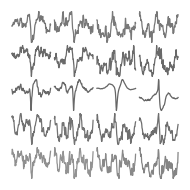

In [14]:
# get unit waveforms and align
wfs = We.get_waveforms(CELL_ID)
wfs_aligned = align_waveforms(wfs, ref_channel=NEARBY_CHANNEL)

# compute aligned median template
median_spike = np.median(wfs_aligned, axis=0)  # shape: (n_samples, n_channels)

# median_spike is already peak-aligned from previous block
min_s = median_spike.min(axis=0)
max_s = median_spike.max(axis=0)
peak_to_peak_amp = max_s - min_s

# colors = plt.cm.turbo(np.linspace(0, 1, 128))
colors = plt.cm.gray(np.linspace(0.6, 0.4, 128))

# color each peak to peak amplitude
df = pd.DataFrame(
    {"ppa": peak_to_peak_amp, "contact": np.arange(0, 128, 1)}
).sort_values(by="ppa", ascending=True)
df["colors"] = colors.tolist()
df = df.sort_values(by="contact")  # back to contact order

# select contacts nearby cell to display
contact_grid = contact_ids[
    [37, 38, 39, 40, 53, 54, 55, 56, 69, 70, 71, 72, 85, 86, 87, 88, 100, 101, 102, 103]
].reshape(5, 4)

# setup plot
fig, axes = plt.subplots(contact_grid.shape[0], contact_grid.shape[1], figsize=(2, 2))

# plot
for ix in range(contact_grid.shape[0]):
    for jx in range(contact_grid.shape[1]):
        ch = contact_grid[ix, jx]
        axes[ix, jx].plot(
            median_spike[:, ch],
            color=df["colors"].iloc[ch],  # index by channel id, not c_i
            linewidth=0.9,
        )
        axes[ix, jx].axis("off")
        # axes[ix, jx].set_title(ch, fontsize=8)

plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)
plt.savefig("figures/8_source_data/fig3f/fig3f.svg", bbox_inches="tight", **savefig_cfg)

## Create source dataset

In [15]:
# save source data
records = []
for ix in range(contact_grid.shape[0]):
    for jx in range(contact_grid.shape[1]):
        ch = contact_grid[ix, jx]
        color = df["colors"].iloc[ch]
        for t, v in enumerate(median_spike[:, ch]):
            records.append(
                {
                    "row": ix,
                    "col": jx,
                    "channel": ch,
                    "time": t,
                    "voltage": v,
                    "r": color[0],
                    "g": color[1],
                    "b": color[2],
                    "a": color[3],
                }
            )

df_source = pd.DataFrame(records)
df_source.to_excel("figures/8_source_data/fig3f/fig3f.xlsx", index=False)
display(df_source)

,row,col,channel,time,voltage,r,g,b,a
0,0,0,37,0,-0.111377,0.458824,0.458824,0.458824,1.0
1,0,0,37,1,-0.112630,0.458824,0.458824,0.458824,1.0
2,0,0,37,2,-0.056640,0.458824,0.458824,0.458824,1.0
3,0,0,37,3,-0.073221,0.458824,0.458824,0.458824,1.0
4,0,0,37,4,0.004983,0.458824,0.458824,0.458824,1.0
...,...,...,...,...,...,...,...,...,...
2395,4,3,103,115,-0.122468,0.517647,0.517647,0.517647,1.0
2396,4,3,103,116,-0.088777,0.517647,0.517647,0.517647,1.0
2397,4,3,103,117,-0.021988,0.517647,0.517647,0.517647,1.0
2398,4,3,103,118,-0.020710,0.517647,0.517647,0.517647,1.0


## Load and plot

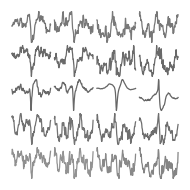

In [8]:
# load
df_source = pd.read_excel("figures/8_source_data/fig3f/fig3f.xlsx")

# get grid dimensions
n_rows = df_source["row"].max() + 1
n_cols = df_source["col"].max() + 1

# setup plot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2, 2))

# plot
for (row, col, ch), group in df_source.groupby(["row", "col", "channel"]):
    color = group[["r", "g", "b", "a"]].iloc[0].values
    axes[row, col].plot(
        group["time"],
        group["voltage"],
        color=color,
        linewidth=0.9,
    )
    axes[row, col].axis("off")

plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()